# Plotting Soundings

*Last updated April 28, 2026*

In this notebook we go through code for plotting atmospheric soundings using MetPty. This is really just modification of a MetPy demo called ["Simple Sounding" linked here](https://unidata.github.io/MetPy/latest/examples/plots/Simple_Sounding.html#sphx-glr-examples-plots-simple-sounding-py). The data loading and cleaning is tailored specifically to fit csv files obtained from [UWYO's sounding archive](https://weather.uwyo.edu/upperair/sounding_legacy.html).

This assumes you have already downloaded the data from UWYO yourself. 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import metpy.calc as mpcalc
from metpy.plots import add_metpy_logo, SkewT
from metpy.units import units

plt.rcParams["figure.figsize"] = (7, 7)
plt.rc("font", family="serif")

First, we create a helper function for loading and cleaning the data. 

In [2]:
def load_and_clean_sounding(path_to_data):
    """
    Produces a pandas dataframe from a UWYO sounding file located
    at path_to_data. 
    """
    df = pd.read_csv(path_to_data, usecols=[0, 3, 4, 5, 6, 11, 12])

    # Drop invalid row names
    df = df.dropna(
        subset=(
            "temperature_C", 
            "dew point temperature_C", 
            "wind direction_degree",
            "wind speed_m/s"
        ), 
        how="all"
    ).reset_index(drop=True)

    # sometimes surface vars are funny so drop them
    df = df.iloc[1:]
    
    return df 

For plotting, we need to unpack the columns of the dataframe. 

In [3]:
def process_vars(df):
    """
    Separates the columns of a sounding dataframe into individual variables
    needed for our plotting functions. 

    Keeps track of units explicitly w/ MetPy. 
    """
    # Thermo variables 
    p = df["pressure_hPa"].values * units.hPa
    T = df["temperature_C"].values * units.degC
    Td = df["dew point temperature_C"].values * units.degC

    # Wind velocity
    wind_speed_raw = np.array([float(ws) for ws in df["wind speed_m/s"].values])
    wind_speed = wind_speed_raw * units("m/s")
    wind_dir_raw = np.array([float(wd) for wd in df["wind direction_degree"].values])
    wind_dir = wind_dir_raw * units.degrees
    u, v = mpcalc.wind_components(wind_speed, wind_dir)
    
    return p, T, Td, u, v

Next, we define functions *only* for producing plots. 

In [4]:
def make_skewT_from_df(df, outfile_name = None, save_fig = False, show_fig = True):
    """
    Creates a skewT-logP plot of a sounding that is encoded in a dataframe. 
    """
    p, T, Td, u, v = process_vars(df) 
    
    skew = SkewT()

    skew.plot(p, T, "xkcd:pumpkin")
    skew.plot(p, Td, "xkcd:eggplant")

    skew.ax.set_xlabel("Temperature (\N{DEGREE CELSIUS})", fontsize=18)
    skew.ax.set_ylabel("Pressure (hPa)", fontsize=18)
    plt.xticks(fontsize=16, rotation=0)
    plt.yticks(fontsize=16, rotation=0)

    my_interval = np.arange(100, 1000, 50) * units("hPa")

    ix = mpcalc.resample_nn_1d(p, my_interval)

    skew.plot_barbs(p[ix], u[ix], v[ix])

    skew.plot_dry_adiabats()
    skew.plot_moist_adiabats()
    skew.plot_mixing_lines()
    skew.ax.set_ylim(1000, 150)
    skew.ax.set_xlim(-46, 20)

    if save_fig:
        plt.savefig(outfile_name, dpi = 600, bbox_inches = "tight")

    if show_fig:
        plt.show() 

    return None 

In [5]:
def make_skewT(path_to_data, outfile_name = None, save_fig = False, show_fig = True):
    """
    Creates a skewT-logP plot of a sounding (w/ UWYO conventions) encoded in a file
    path_to_data. 
    """
    df = load_and_clean_sounding(path_to_data)

    make_skewT_from_df(
        df, 
        outfile_name = outfile_name, 
        save_fig = save_fig, 
        show_fig = show_fig,
    )
    
    return None

With all that taken care of, we simply call `make_skewT` on both the morning and evening soundings. 

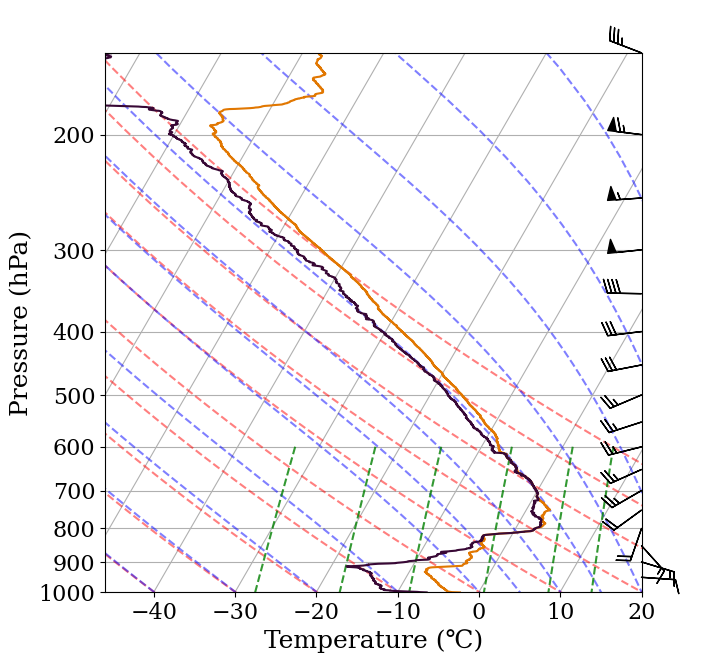

In [8]:
path_to_data_morning = "Maniwaki-Soundings/2023040512-71722.csv" # of course, change the path as required on your machine!
outfile_name_morning = "skewT_2023040512"

make_skewT(
    path_to_data_morning, 
    outfile_name = outfile_name_morning, 
    save_fig = False, 
    show_fig = True, 
)

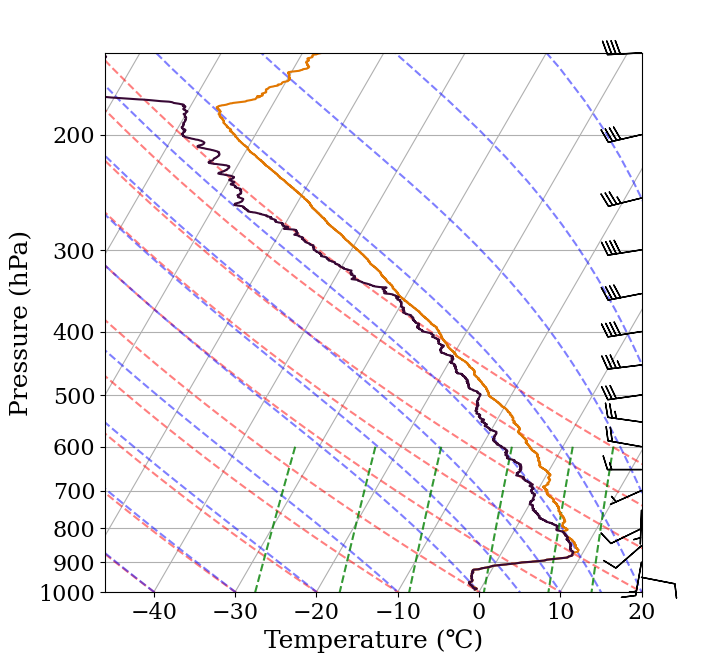

In [9]:
path_to_data_evening = "Maniwaki-Soundings/2023040600-71722.csv"
outfile_name_evening = "skewT_2023040600"

make_skewT(
    path_to_data_evening, 
    outfile_name = outfile_name_evening,
    save_fig = False,
    show_fig = True,
)